# Anisotropic Gaussian Orientation Bank step-edge example

A bank of rotated anisotropic Gaussian derivative kernels. This notebook creates a simple black-to-white step edge, runs the filter, and plots the result.


## How this filter works

This angular filter builds a bank of rotated anisotropic Gaussian derivative kernels. Each angle produces its own response image, which lets you inspect orientation-specific edges or collapse the bank back to gradient-like `gradient_x` and `gradient_y` outputs.

### Paper reference

This implementation uses fixed rotated kernels. The closest references are Freeman and Adelson's 1991 steerable-filter paper, DOI [10.1109/34.93808](https://doi.org/10.1109/34.93808), and Perona's 1995 deformable-kernel paper, DOI [10.1109/34.391394](https://doi.org/10.1109/34.391394). Links. [Steerable filter](https://en.wikipedia.org/wiki/Steerable_filter).


## Setup

Import the small set of tools used in this notebook. The autoreload lines help Jupyter pick up local source edits without restarting the kernel every time.


In [1]:
# Imports and local reloads.
%load_ext autoreload
%autoreload 2

import time

import matplotlib.pyplot as plt
import torch

from agfb_filters import (
    ExecutionPath,
    collapse_orientation_bank,
    get_filter_definition,
    run_orientation_bank,
)

## Filter settings

Choose the filter settings here. The `definition` describes the filter, and the `path` chooses the matching execution path.


In [7]:
# Change these settings to try the filter.
angle_count = 12
sigma_parallel = 1.0
sigma_perpendicular = 10.0
definition = get_filter_definition(
    "anisotropic_gaussian_orientation_bank",
    angle_count=angle_count,
    sigma_parallel=sigma_parallel,
    sigma_perpendicular=sigma_perpendicular,
)
path = ExecutionPath.ORIENTATION_BANK

## Test image

Create a test image. By default this is a synthetic step edge. The commented block lets you replace it with your own image file path.


(np.float64(-0.5), np.float64(1023.5), np.float64(1023.5), np.float64(-0.5))

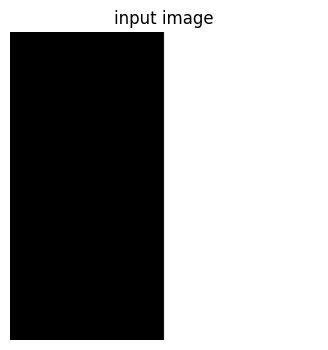

In [8]:
# Build the step-edge test image.
size = 1024
image = torch.zeros(1, size, size)
image[:, :, size // 2 :] = 1.0

# To use your own image instead, uncomment this block and set image_path.
# image_path = "path/to/image.png"
# image = torch.as_tensor(plt.imread(image_path), dtype=torch.float32)
# if image.ndim == 3:
#     image = image[..., :3].mean(dim=-1)
# image = image.unsqueeze(0)

plt.figure(figsize=(4, 4))
plt.imshow(image[0], cmap="gray", vmin=0, vmax=1)
plt.title("input image")
plt.axis("off")

## Angular kernel weights

Visualize one angular filter kernel. Change `angle_index` to inspect a different orientation in the bank.


(np.float64(-0.5), np.float64(60.5), np.float64(60.5), np.float64(-0.5))

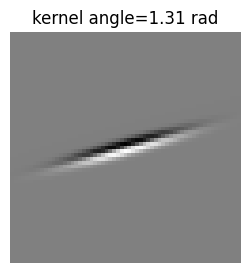

In [12]:
# Plot one angular kernel.
angle_index = 5
implementation = definition.require_implementation()
kernel = implementation.orientation_kernels[angle_index]
angle = float(implementation.angles[angle_index])
weight_limit = float(kernel.abs().max())

plt.figure(figsize=(4, 3))
plt.imshow(kernel, cmap="gray", vmin=-weight_limit, vmax=weight_limit)
plt.title(f"kernel angle={angle:.2f} rad")
plt.axis("off")

## Run the orientation bank

Run the orientation bank. The raw result has one response image per angle. The collapsed result turns the bank into `gradient_x` and `gradient_y` for plotting.


In [13]:
# Time the orientation bank call.
start = time.perf_counter()
result = run_orientation_bank(
    definition,
    image,
    path=path,
    boundary=definition.default_boundary,
)
collapsed = collapse_orientation_bank(
    result,
    mode="least_squares_projection",
)
elapsed = time.perf_counter() - start

print(f"{elapsed:.4f} seconds")

5.9668 seconds


## Orientation results

Plot one raw angular response and the collapsed gradient outputs. The same grayscale range is used for the two collapsed gradients.


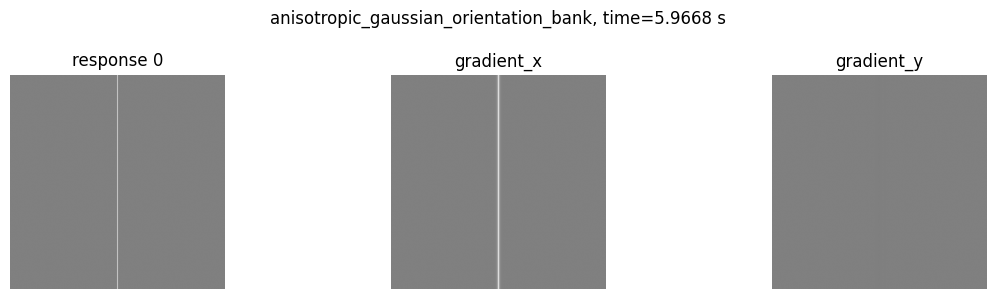

In [14]:
# Plot one bank response and the collapsed gradients.
angle_index = 0
response = result.responses[0, angle_index]
gradient_x = collapsed.gradient_x
gradient_y = collapsed.gradient_y
gradient_limit = max(float(gradient_x.abs().max()), float(gradient_y.abs().max()))
response_limit = float(response.abs().max())

fig, axes = plt.subplots(1, 3, figsize=(12, 3))

axes[0].imshow(response, cmap="gray", vmin=-response_limit, vmax=response_limit)
axes[0].set_title(f"response {angle_index}")

axes[1].imshow(gradient_x[0], cmap="gray", vmin=-gradient_limit, vmax=gradient_limit)
axes[1].set_title("gradient_x")

axes[2].imshow(gradient_y[0], cmap="gray", vmin=-gradient_limit, vmax=gradient_limit)
axes[2].set_title("gradient_y")

for ax in axes:
    ax.axis("off")

fig.suptitle(f"{definition.name}, time={elapsed:.4f} s")
fig.tight_layout()